In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm 
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
ds = xr.open_dataset(r'../data/amazon2.nc')

In [3]:
A = 6371.0e3  # radio terrestre en metros

# Selecciona los campos de velocidad
u = ds.uo.isel(time=0)
v = ds.vo.isel(time=0)

# --------------------------
# 1. CÁLCULO DE DX, DY, DZ
# --------------------------

dy = np.deg2rad(ds.latitude.shift(latitude=-1) - ds.latitude) * A
dx = (
    np.deg2rad(ds.longitude.shift(longitude=-1) - ds.longitude)
    * A * np.cos(np.deg2rad(ds.latitude))
)

In [45]:
# z_mid y dz entre niveles
z_mid = (ds.depth.shift(depth=-1) + ds.depth) / 2
z_mid = z_mid.isel(depth=slice(0, -1))  # 49 niveles, sin NaN
dz = ds.depth.diff('depth')             # también 49 niveles

# --------------------------
# 2. INTERPOLACIÓN A CENTRO DE CELDA
# --------------------------

# dudx al centro horizontal
dudx = (u.shift(longitude=-1) - u) / dx
dudx = (dudx.shift(latitude=-1) + dudx) / 2.0

# dvdy al centro horizontal
dvdy = (v.shift(latitude=-1) - v) / dy
dvdy = (dvdy.shift(longitude=-1) + dvdy) / 2.0

# lat/lon en el centro
lon_c = (ds.longitude.shift(longitude=-1) + ds.longitude) / 2
lat_c = (ds.latitude.shift(latitude=-1) + ds.latitude) / 2

# Ajustar coordenadas y recortar bordes (porque hicimos shift)
dudx = dudx.assign_coords(longitude=lon_c, latitude=lat_c).isel(longitude=slice(None, -1), latitude=slice(None, -1))
dvdy = dvdy.assign_coords(longitude=lon_c, latitude=lat_c).isel(longitude=slice(None, -1), latitude=slice(None, -1))

# --------------------------
# 3. DIVERGENCIA HORIZONTAL
# --------------------------

div_h = dudx + dvdy
div_h = div_h.transpose("depth", "latitude", "longitude")

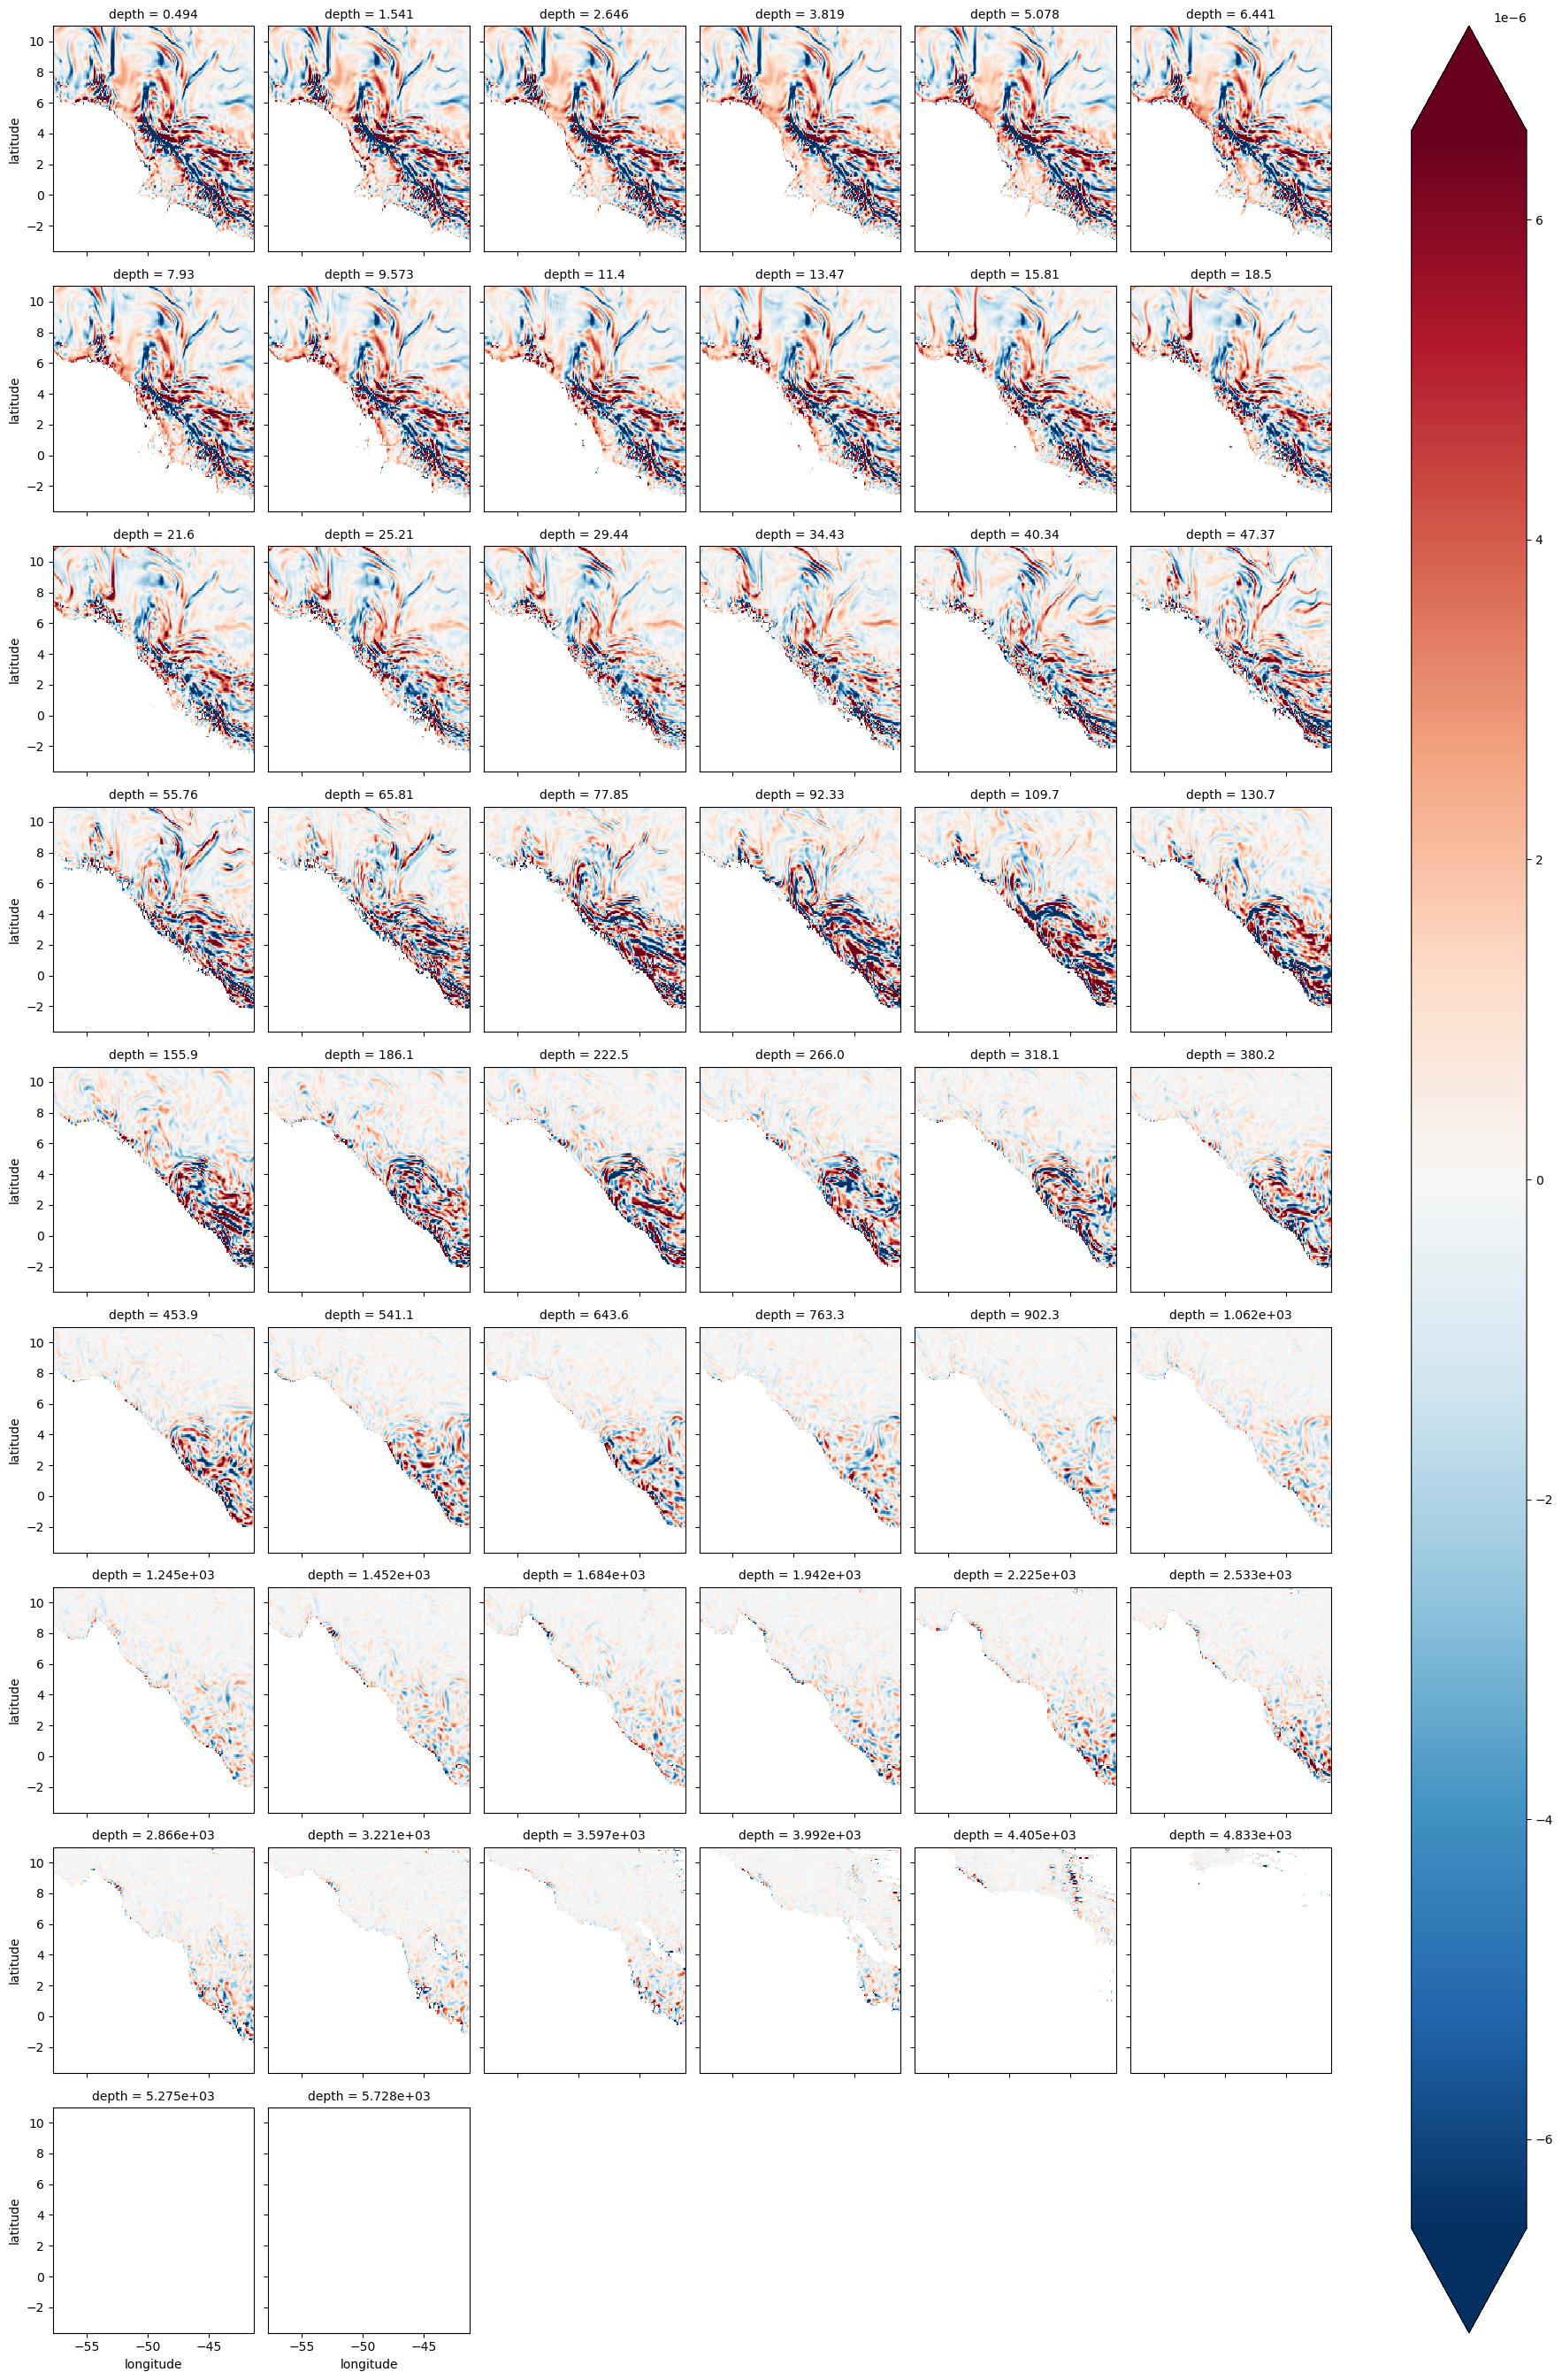

In [46]:
div_h.plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

In [6]:
# --------------------------
# 4. INTEGRACIÓN BOTTOM-UP
# --------------------------

# Broadcast dz al shape de div_h
dz_3d = dz.broadcast_like(div_h.isel(depth=slice(0, -1)))

# Paso 1: calculamos el integrando
integrand = (-div_h.isel(depth=slice(0, -1))) * dz_3d  # [m/s]

# Paso 2: integración acumulativa desde el fondo
integrand_rev = integrand.isel(depth=slice(None, None, -1))
w_bottom_up = integrand_rev.cumsum(dim="depth", skipna=True)
w_bottom_up = w_bottom_up.isel(depth=slice(None, None, -1))  # reordenar

# Paso 3: asignar coordenadas de profundidad intermedia
w_bottom_up = w_bottom_up.assign_coords(depth=z_mid)
w_bottom_up.name = "w_bottom_up"

# Paso 4: (opcional) interpolar al centro del grid T
w_Tgrid = ((w_bottom_up + w_bottom_up.shift(depth=-1)) / 2).fillna(0)
w_Tgrid.name = "w_Tgrid"

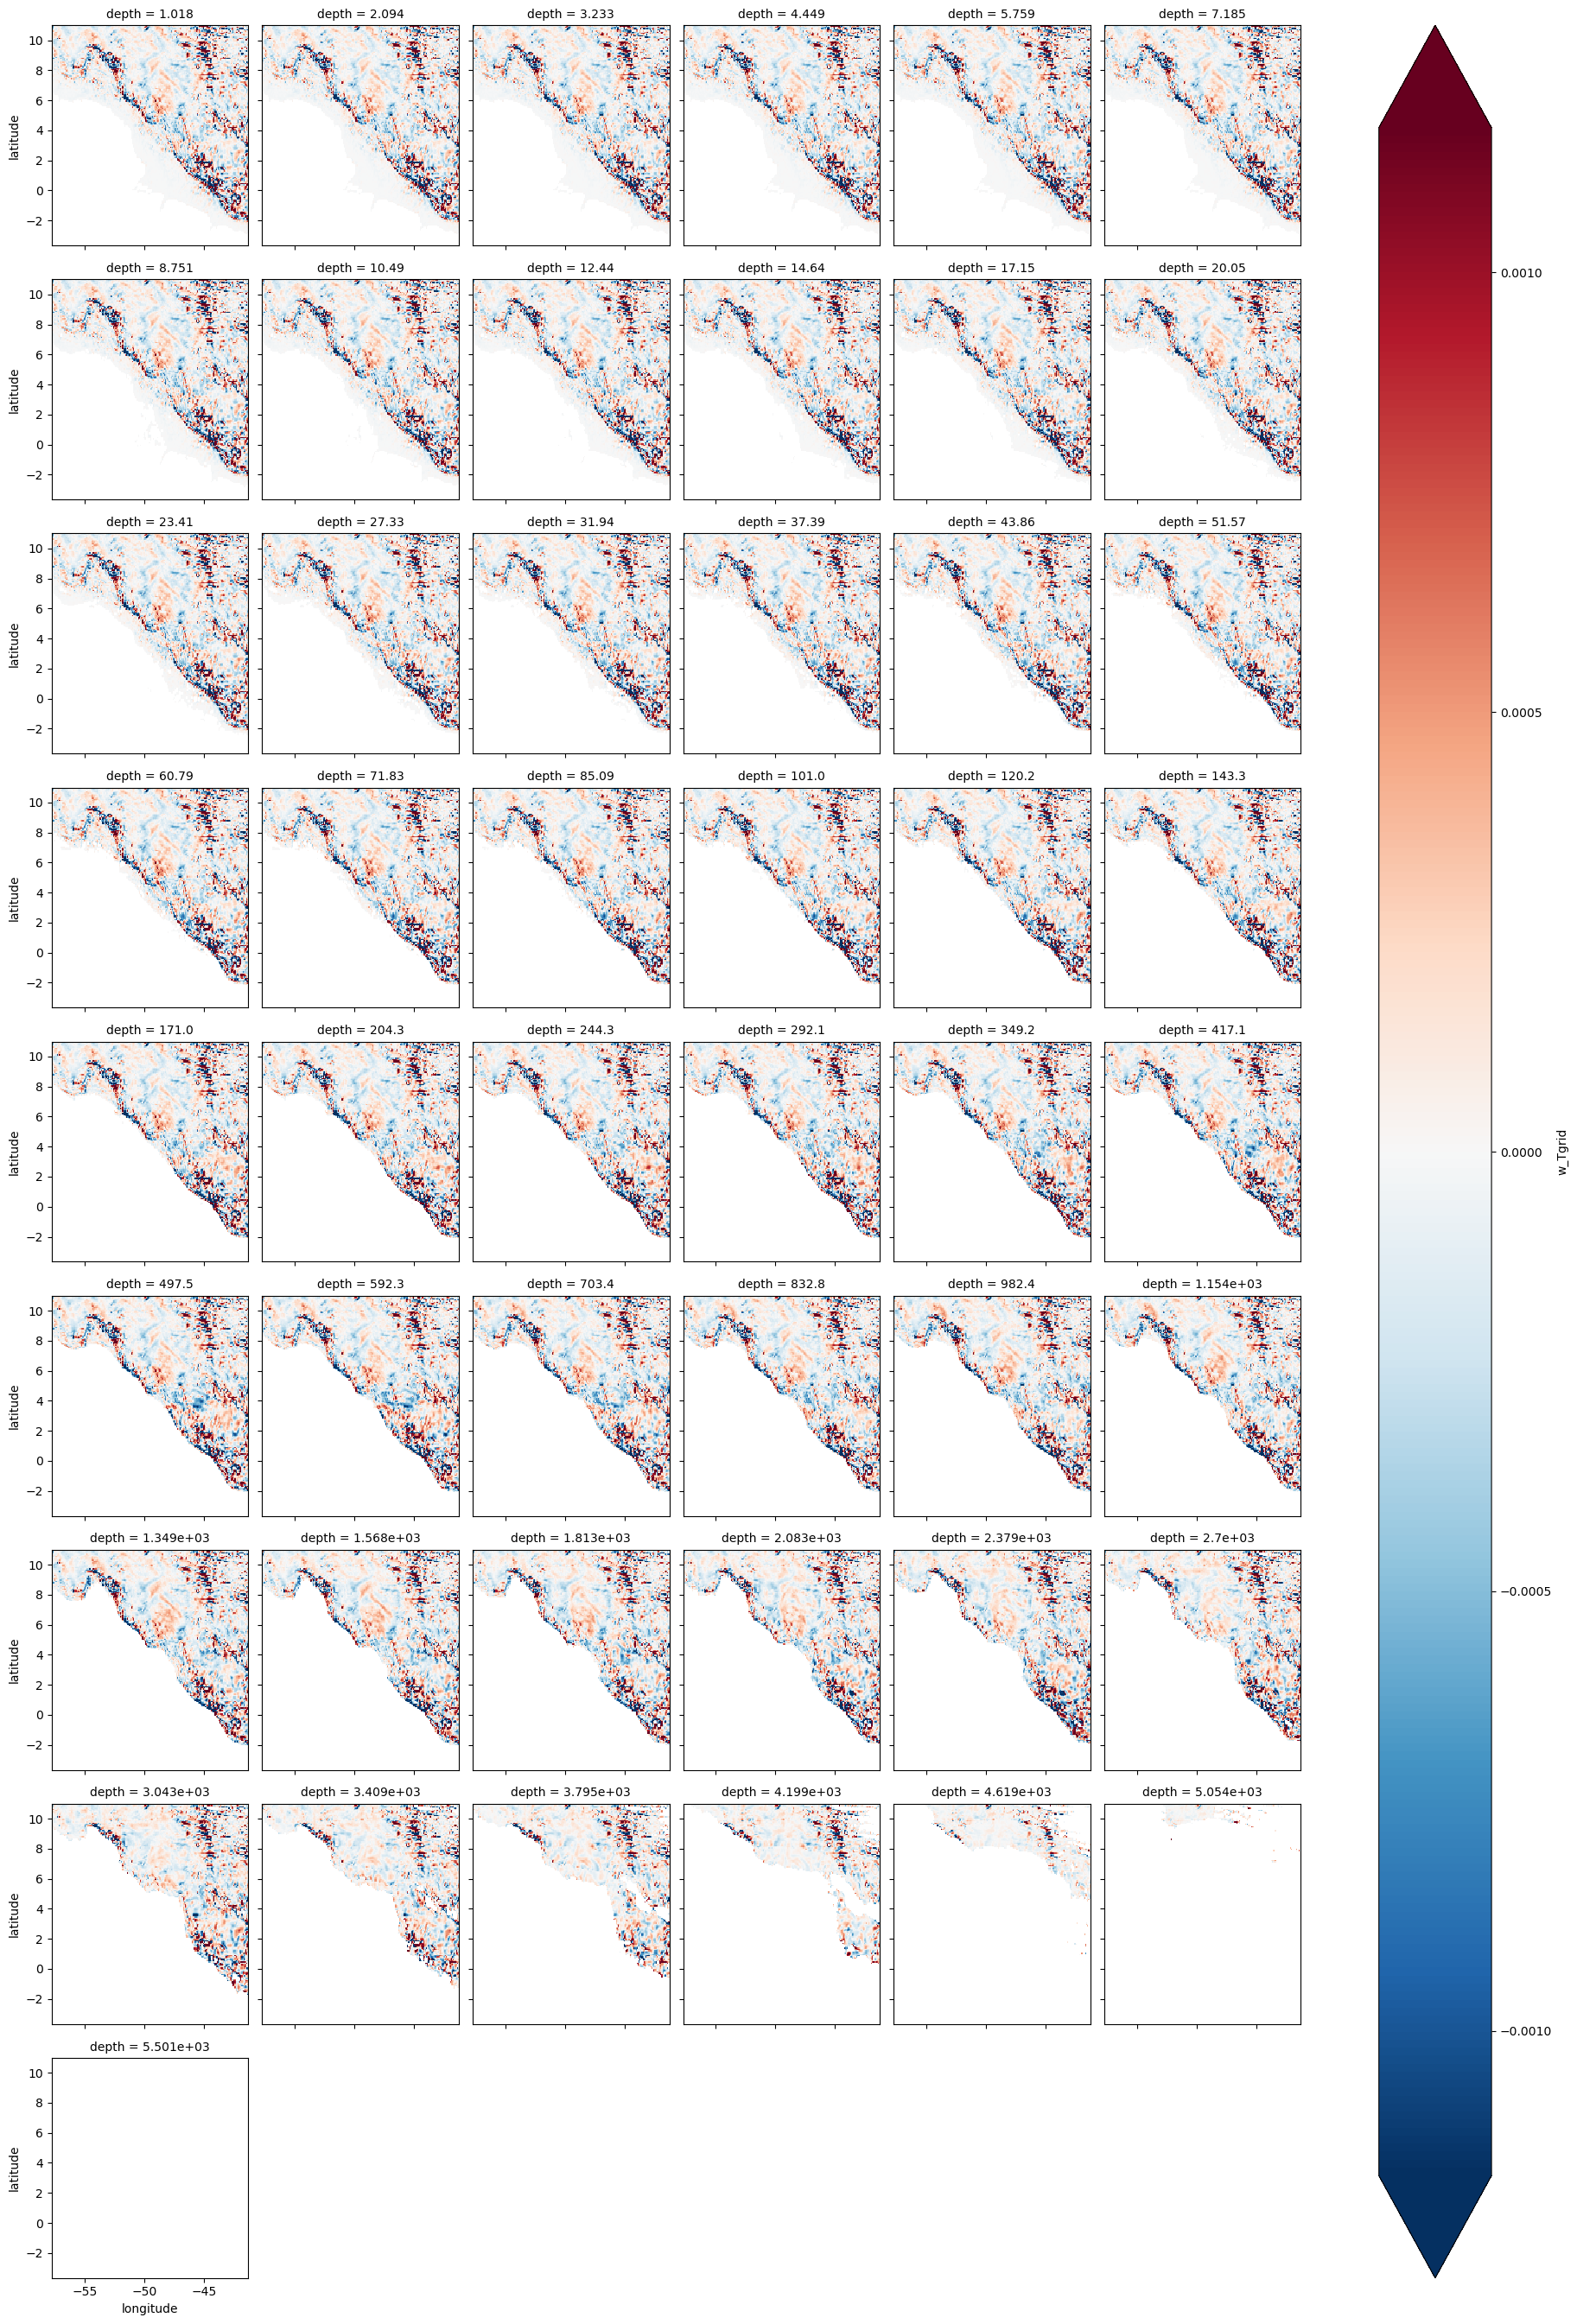

In [13]:
w_Tgrid = w_Tgrid.where(w_Tgrid!=0,np.nan)
w_Tgrid.plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

In [15]:
u=ds.uo.isel(time=0,longitude=slice(98,100),latitude=slice(98,100))
v=ds.vo.isel(time=0,longitude=slice(98,100),latitude=slice(98,100))
w=w_Tgrid.isel(longitude=slice(98,100),latitude=slice(98,100))

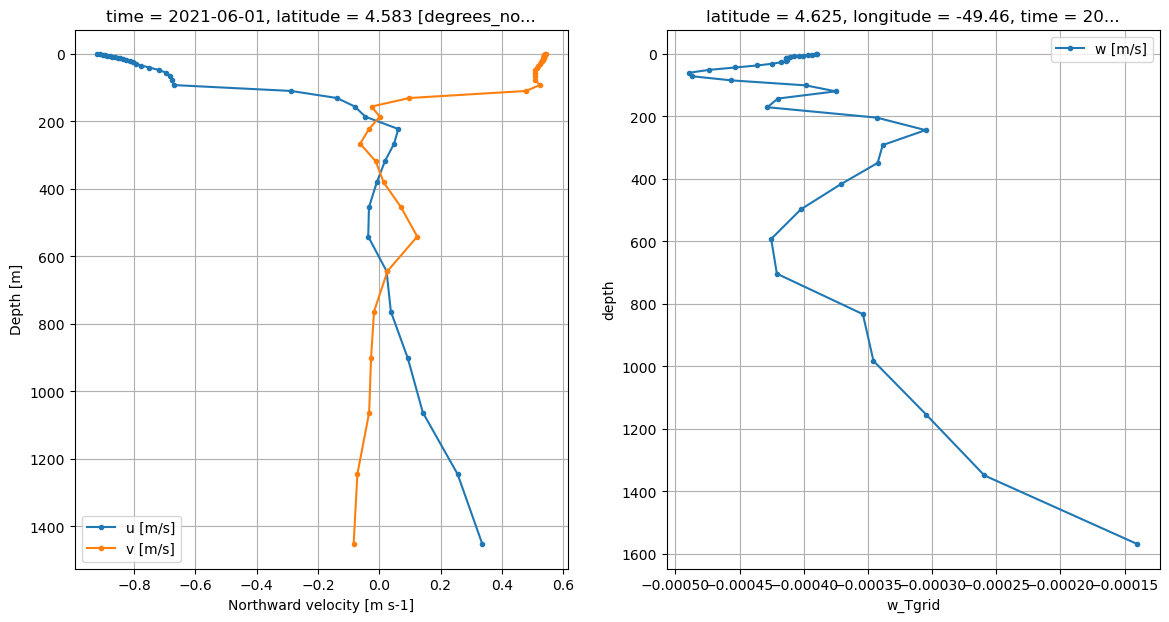

In [19]:
fig,ax = plt.subplots(1,2,figsize=(14,7))

u.isel(longitude=1,latitude=1).plot(y='depth',marker='.',label='u [m/s]',ax=ax[0])
v.isel(longitude=1,latitude=1).plot(y='depth',marker='.', label='v [m/s]',ax=ax[0])
ax[0].invert_yaxis()
ax[0].grid('minor')
ax[0].legend()
# ax[0].set_title("U and V profile")

w.isel(longitude=1,latitude=1).plot(y='depth',marker='.', label='w [m/s]',ax=ax[1])
# ax[1].set_ylim(0,1500)
ax[1].invert_yaxis()
ax[1].grid('minor')
ax[1].legend()
# ax[1].set_title("W profile")

plt.legend()

In [49]:
u.depth.values

array([4.940250e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00,
       5.078224e+00, 6.440614e+00, 7.929560e+00, 9.572997e+00,
       1.140500e+01, 1.346714e+01, 1.581007e+01, 1.849556e+01,
       2.159882e+01, 2.521141e+01, 2.944473e+01, 3.443415e+01,
       4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02,
       1.558507e+02, 1.861256e+02, 2.224752e+02, 2.660403e+02,
       3.181274e+02, 3.802130e+02, 4.539377e+02, 5.410889e+02,
       6.435668e+02, 7.633331e+02, 9.023393e+02, 1.062440e+03,
       1.245291e+03, 1.452251e+03, 1.684284e+03, 1.941893e+03,
       2.225078e+03, 2.533336e+03, 2.865703e+03, 3.220820e+03,
       3.597032e+03, 3.992484e+03, 4.405224e+03, 4.833291e+03,
       5.274784e+03, 5.727917e+03], dtype=float32)

In [51]:
z_mid.values

array([1.01769996e+00, 2.09352207e+00, 3.23258209e+00, 4.44885969e+00,
       5.75941944e+00, 7.18508720e+00, 8.75127888e+00, 1.04889984e+01,
       1.24360695e+01, 1.46386051e+01, 1.71528149e+01, 2.00471897e+01,
       2.34051151e+01, 2.73280716e+01, 3.19394417e+01, 3.73890991e+01,
       4.38588715e+01, 5.15689926e+01, 6.07857780e+01, 7.18305588e+01,
       8.50899658e+01, 1.01027687e+02, 1.20197647e+02, 1.43258347e+02,
       1.70988144e+02, 2.04300400e+02, 2.44257751e+02, 2.92083862e+02,
       3.49170227e+02, 4.17075378e+02, 4.97513306e+02, 5.92327881e+02,
       7.03449951e+02, 8.32836182e+02, 9.82389648e+02, 1.15386548e+03,
       1.34877100e+03, 1.56826758e+03, 1.81308850e+03, 2.08348535e+03,
       2.37920703e+03, 2.69951953e+03, 3.04326147e+03, 3.40892603e+03,
       3.79475781e+03, 4.19885400e+03, 4.61925781e+03, 5.05403760e+03,
       5.50135059e+03], dtype=float32)